In [3]:
import numpy as np
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(42)

# Read the CSV file into a DataFrame
df = pd.read_csv('../Assignment 4/Mall_Customers.csv', index_col='CustomerID')

# Display the first few rows of the DataFrame
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


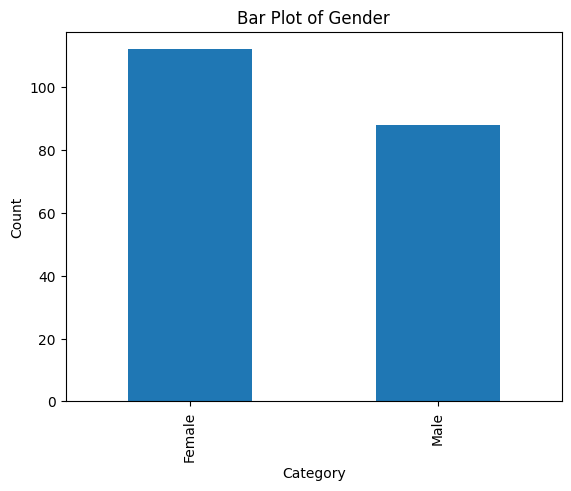

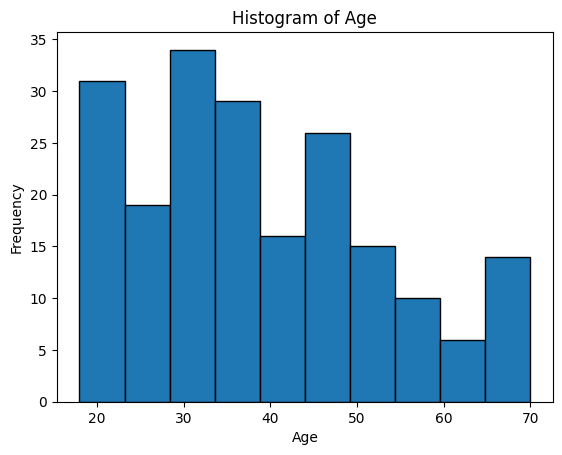

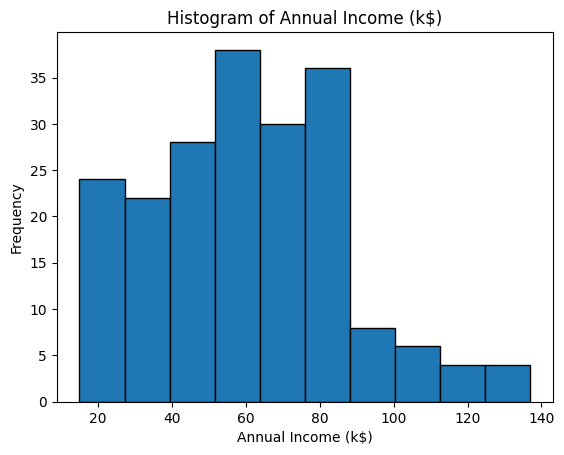

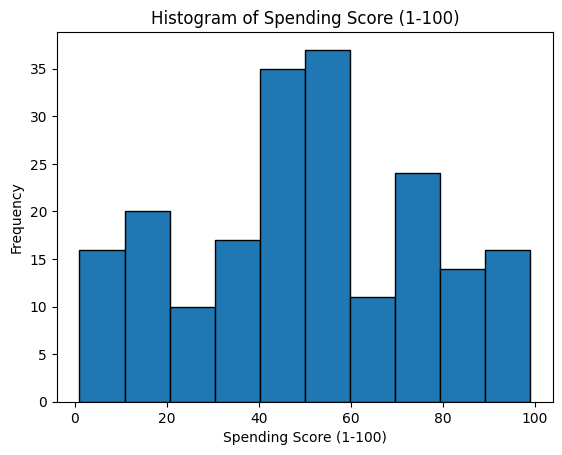

In [4]:
import matplotlib.pyplot as plt

# Convert the character column to a categorical variable
df['Gender'] = df['Gender'].astype('category')

# Create a bar plot for the categorical variable
plt.figure()
df['Gender'].value_counts().plot(kind='bar')
plt.title('Bar Plot of Gender')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

# Create histograms for each numerical variable
for column in df.columns:
    if column != 'Gender':  # Exclude the non-numeric variable
        plt.figure()
        plt.hist(df[column], bins=10, edgecolor='black')
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()


In [5]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()
print(missing_values)

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler

# Perform feature scaling on numeric variables
scaler = StandardScaler()
numeric_columns = df.select_dtypes(include=['int64']).columns
scaled_features = scaler.fit_transform(df[numeric_columns])

# Convert the scaled features back to a DataFrame
df_preprocessed = pd.DataFrame(scaled_features, index=df.index, columns=numeric_columns)

# Encode the categorical variable
df_preprocessed['Gender'] = df['Gender'].cat.codes

# Display the first few rows of the scaled DataFrame
df_preprocessed.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender
CustomerID,,,,
1,-1.424569,-1.738999,-0.434801,1
2,-1.281035,-1.738999,1.195704,1
3,-1.352802,-1.700830,-1.715913,0
4,-1.137502,-1.700830,1.040418,0
5,-0.563369,-1.662660,-0.395980,0


In [12]:
from sklearn.cluster import KMeans, Birch, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture

# Define a function to evaluate clustering algorithms
def evaluate_clustering(data, algorithm, param_grid):
    best_params = {'silhouette': None, 'davies_bouldin': None}
    best_silhouette = -1
    best_davies_bouldin = float('inf')

    for params in param_grid:
        model = algorithm(**params)
        labels = model.fit_predict(data)
        if max(labels) == -1:
            continue  # Skip DBSCAN models without any clusters
        silhouette = silhouette_score(data, labels)
        davies_bouldin = davies_bouldin_score(data, labels)

        if silhouette > best_silhouette:
            best_silhouette = silhouette
            best_params['silhouette'] = params
        if davies_bouldin < best_davies_bouldin:
            best_davies_bouldin = davies_bouldin
            best_params['davies_bouldin'] = params

    return best_params, best_silhouette, best_davies_bouldin

# Evaluate each clustering algorithm to find the best parameters. (Hyperparameter tuning)
results = pd.DataFrame()

for name, algorithm, param_grid in [
    ('K-means', KMeans, [{'n_clusters': k} for k in range(2, 11)]),
    ('Birch', Birch, [{'n_clusters': k} for k in range(2, 11)]),
    ('DBSCAN', DBSCAN, [{'eps': eps, 'min_samples': min_samples} for eps in [0.4, 0.6, 0.8, 1.0] for min_samples in range(3, 11)]),
    ('Gaussian Mixture', GaussianMixture, [{'n_components': k} for k in range(2, 11)])
]:
    best_params, best_silhouette, best_davies_bouldin = evaluate_clustering(df_preprocessed, algorithm, param_grid)
    results = pd.concat([results, pd.DataFrame({
        'Algorithm': [name],
        'Silhouette Score': [best_silhouette],
        'Best Parameters (silhouette)': [best_params['silhouette']],
        'Davies-Bouldin Index': [best_davies_bouldin],
        'Best Parameters (davies_bouldin)': [best_params['davies_bouldin']]
    })], ignore_index=True)

print(results)



          Algorithm  Silhouette Score    Best Parameters (silhouette)  \
0           K-means          0.355420               {'n_clusters': 5}   
1             Birch          0.351523               {'n_clusters': 6}   
2            DBSCAN          0.113055  {'eps': 0.6, 'min_samples': 3}   
3  Gaussian Mixture          0.332317             {'n_components': 5}   

   Davies-Bouldin Index Best Parameters (davies_bouldin)  
0              1.000869                {'n_clusters': 7}  
1              1.002266                {'n_clusters': 7}  
2              1.582553   {'eps': 0.4, 'min_samples': 3}  
3              1.038311              {'n_components': 5}  
